# BAGS-python — Example Notebook

**BAGS** (*Bedload Assessment for Gravel-bed Streams*) is a tool developed by the
USDA Forest Service Stream Systems Technology Center (<http://www.stream.fs.fed.us/>)
for predicting bedload sediment transport in gravel-bed rivers.

This notebook walks through each of the six implemented equations using a single
hypothetical channel, then demonstrates calibration and Monte Carlo uncertainty analysis.

> **Reference:** Pitlick, J., Cui, Y., & Wilcock, P. (2009).
> *Manual for computing bed load transport using BAGS software.*
> RMRS-GTR-223. USDA Forest Service. https://doi.org/10.2737/RMRS-GTR-223

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from bags.data import GrainSizeDistribution, ChannelGeometry
from bags.equations import parker90, parker82, wilcock01, wilcock03, bakke99
from bags.grain_size import percentile

## 1. Define channel and grain-size distribution

We use a simple gravel-bed channel:
- Slope S = 0.005 m/m
- Bankfull width W = 20 m
- Surface GSD representative of a coarse gravel reach

In [2]:
# Surface grain-size distribution (sizes in mm, cumulative % finer)
surface_gsd = GrainSizeDistribution(
    sizes_mm  = [1,   2,   4,   8,  16,  32,  64, 128],
    finer_pct = [2,   8,  18,  35,  60,  82,  95, 100],
)

# Substrate GSD (slightly finer — less armoured)
substrate_gsd = GrainSizeDistribution(
    sizes_mm  = [1,   2,   4,   8,  16,  32,  64],
    finer_pct = [5,  15,  30,  52,  75,  92, 100],
)

# Channel geometry
geom = ChannelGeometry(slope=0.005, width=20.0)

# Key grain sizes
print(f"Surface  D50 = {percentile(surface_gsd, 50):.1f} mm    D90 = {percentile(surface_gsd, 90):.1f} mm")
print(f"Substrate D50 = {percentile(substrate_gsd, 50):.1f} mm    D90 = {percentile(substrate_gsd, 90):.1f} mm")

Surface  D50 = 12.1 mm    D90 = 49.0 mm
Substrate D50 = 7.5 mm    D90 = 29.5 mm


### Plot the grain-size distributions

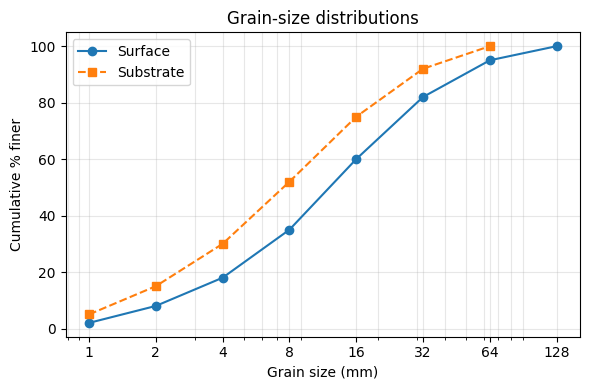

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(surface_gsd.sizes_mm, surface_gsd.finer_pct, 'o-', label='Surface')
ax.semilogx(substrate_gsd.sizes_mm, substrate_gsd.finer_pct, 's--', label='Substrate')
ax.set_xlabel('Grain size (mm)')
ax.set_ylabel('Cumulative % finer')
ax.set_title('Grain-size distributions')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128])
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Single-discharge example — all equations at Q = 50 m³/s

In [4]:
Q = 50.0  # m³/s

r90   = parker90.transport_rate(Q, geom, surface_gsd)
rPK   = parker82.transport_rate(Q, geom, substrate_gsd, use_pkm=False)
rPKM  = parker82.transport_rate(Q, geom, substrate_gsd, use_pkm=True)
rD50  = parker82.transport_rate_d50(Q, geom, D50_mm=percentile(substrate_gsd, 50))
rW03  = wilcock03.transport_rate(Q, geom, surface_gsd)

print(f"{'Equation':<35} {'Total (kg/s)':>12}  {'Depth (m)':>10}  {'Shields φ':>10}")
print('-' * 72)
for label, r in [
    ('Parker (1990)', r90),
    ('Parker & Klingeman (1982) — PK', rPK),
    ('Parker, Klingeman & McLean (1982)', rPKM),
    ('Parker, Klingeman & McLean — D50', rD50),
    ('Wilcock & Crowe (2003)', rW03),
]:
    print(f"{label:<35} {r.total_bedload_kgs:>12.2f}  {r.flow_depth_m:>10.3f}  {r.shields_stress:>10.4f}")

Equation                            Total (kg/s)   Depth (m)   Shields φ
------------------------------------------------------------------------
Parker (1990)                             274.69       0.974      6.7147
Parker & Klingeman (1982) — PK            132.28       0.951      4.3796
Parker, Klingeman & McLean (1982)         137.59       0.951      4.3796
Parker, Klingeman & McLean — D50          144.98       0.951      4.3796
Wilcock & Crowe (2003)                     76.18       0.879      9.7271


## 3. Bedload rating curves — all equations

Sweep a range of discharges to generate transport rating curves.

In [5]:
discharges = np.logspace(np.log10(10), np.log10(200), 40)

def rating_curve(eq_fn, **kwargs):
    rates = []
    for Q in discharges:
        try:
            r = eq_fn(Q, **kwargs)
            rates.append(r.total_bedload_kgs)
        except Exception:
            rates.append(np.nan)
    return np.array(rates)

qs_90  = rating_curve(parker90.transport_rate, geometry=geom, surface_gsd=surface_gsd)
qs_PK  = rating_curve(parker82.transport_rate, geometry=geom, substrate_gsd=substrate_gsd, use_pkm=False)
qs_PKM = rating_curve(parker82.transport_rate, geometry=geom, substrate_gsd=substrate_gsd, use_pkm=True)
qs_W03 = rating_curve(wilcock03.transport_rate, geometry=geom, surface_gsd=surface_gsd)

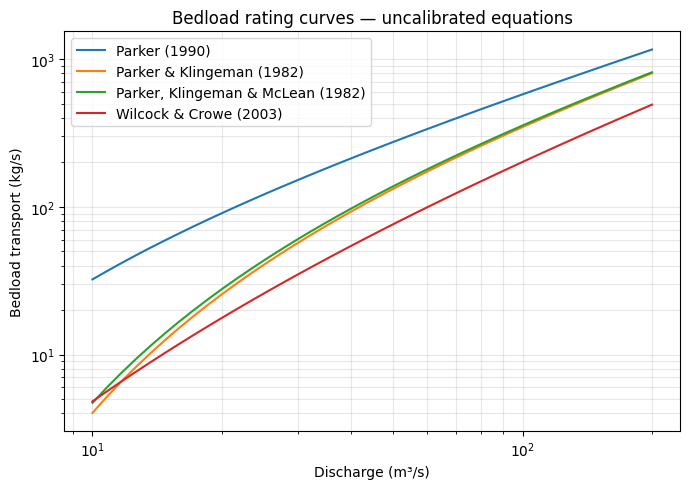

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(discharges, qs_90,  label='Parker (1990)')
ax.loglog(discharges, qs_PK,  label='Parker & Klingeman (1982)')
ax.loglog(discharges, qs_PKM, label='Parker, Klingeman & McLean (1982)')
ax.loglog(discharges, qs_W03, label='Wilcock & Crowe (2003)')
ax.set_xlabel('Discharge (m³/s)')
ax.set_ylabel('Bedload transport (kg/s)')
ax.set_title('Bedload rating curves — uncalibrated equations')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Wilcock (2001) — two-fraction calibrated model

The Wilcock (2001) model requires calibration against observed bedload samples.
We supply synthetic observations here.

In [7]:
# Synthetic observed bedload data
obs_Q      = [15.0, 25.0, 40.0, 60.0, 90.0]   # m³/s
obs_total  = [0.08, 0.50, 2.5,  8.0,  22.0]   # kg/s total bedload
obs_grav_f = [0.85, 0.80, 0.78, 0.75,  0.72]  # gravel fraction (0–1)

TaurG, TaurS = wilcock01.calibrate(
    obs_Q, obs_total, obs_grav_f, geom, surface_gsd
)
print(f"Calibrated  TaurG = {TaurG:.3f} Pa   TaurS = {TaurS:.3f} Pa")

# Predicted vs observed at calibration points
print(f"\n{'Q (m³/s)':>10}  {'Obs (kg/s)':>12}  {'Pred (kg/s)':>12}  {'Gravel pred (kg/s)':>20}")
print('-' * 60)
for Q, qo, fg in zip(obs_Q, obs_total, obs_grav_f):
    r = wilcock01.transport_rate(Q, geom, surface_gsd, TaurG, TaurS)
    print(f"{Q:>10.1f}  {qo:>12.3f}  {r.total_bedload_kgs:>12.3f}  {r.bedload_by_fraction[0]:>20.3f}")

Calibrated  TaurG = 22.143 Pa   TaurS = 16.186 Pa

  Q (m³/s)    Obs (kg/s)   Pred (kg/s)    Gravel pred (kg/s)
------------------------------------------------------------
      15.0         0.080         0.030                 0.010
      25.0         0.500         1.426                 1.281
      40.0         2.500        11.788                11.222
      60.0         8.000        40.066                38.583
      90.0        22.000       102.785                99.362


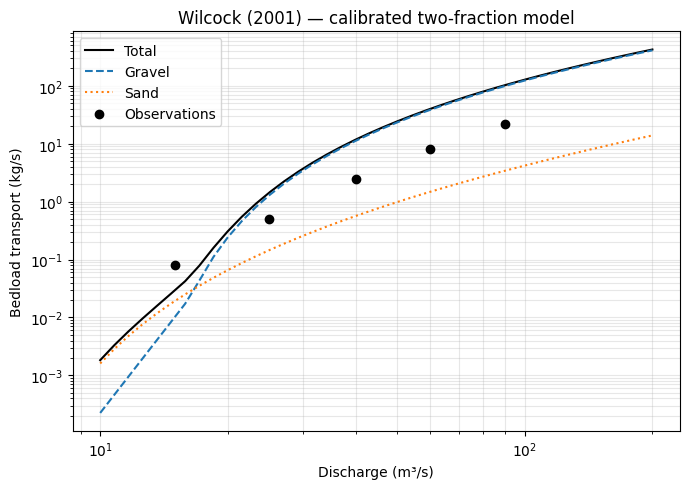

In [8]:
qs_W01 = rating_curve(
    lambda Q, **kw: wilcock01.transport_rate(Q, geom, surface_gsd, TaurG, TaurS),
)
qs_W01_grav = np.array([
    wilcock01.transport_rate(Q, geom, surface_gsd, TaurG, TaurS).bedload_by_fraction[0]
    for Q in discharges
])
qs_W01_sand = qs_W01 - qs_W01_grav

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(discharges, qs_W01,      label='Total', color='black')
ax.loglog(discharges, qs_W01_grav, label='Gravel', linestyle='--')
ax.loglog(discharges, qs_W01_sand, label='Sand',   linestyle=':')
ax.scatter(obs_Q, obs_total, color='black', zorder=5, label='Observations')
ax.set_xlabel('Discharge (m³/s)')
ax.set_ylabel('Bedload transport (kg/s)')
ax.set_title('Wilcock (2001) — calibrated two-fraction model')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Bakke et al. (1999) — calibrated Parker-Klingeman model

Iteratively calibrates the reference Shields stress τ*₅₀ and hiding exponent β.
When observed bedload D₅₀ values are available they constrain β more reliably.

Calibrated  taur50 = 0.1891   beta = 0.0000
(Default Parker-Klingeman values: taur50 = 0.0876, beta = 0.018)


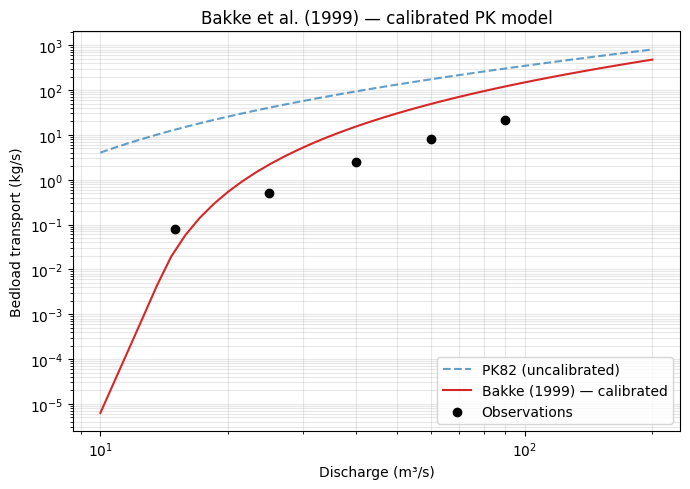

In [9]:
obs_d50_mm = [8.0, 10.0, 12.5, 14.0, 16.0]   # observed bedload D50 at each Q

taur50, beta = bakke99.calibrate(
    obs_Q, obs_total, geom, substrate_gsd,
    observed_d50_mm=obs_d50_mm,
)
print(f"Calibrated  taur50 = {taur50:.4f}   beta = {beta:.4f}")
print(f"(Default Parker-Klingeman values: taur50 = 0.0876, beta = 0.018)")

qs_B99 = rating_curve(
    lambda Q, **kw: bakke99.transport_rate(Q, geom, substrate_gsd, taur50, beta),
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(discharges, qs_PK,  label='PK82 (uncalibrated)', linestyle='--', alpha=0.7)
ax.loglog(discharges, qs_B99, label='Bakke (1999) — calibrated', color='C3')
ax.scatter(obs_Q, obs_total, color='black', zorder=5, label='Observations')
ax.set_xlabel('Discharge (m³/s)')
ax.set_ylabel('Bedload transport (kg/s)')
ax.set_title('Bakke et al. (1999) — calibrated PK model')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Cross-section geometry

All equations support a measured channel cross-section instead of a single bankfull width.
The library computes wetted area and hydraulic radius directly from station-elevation pairs.

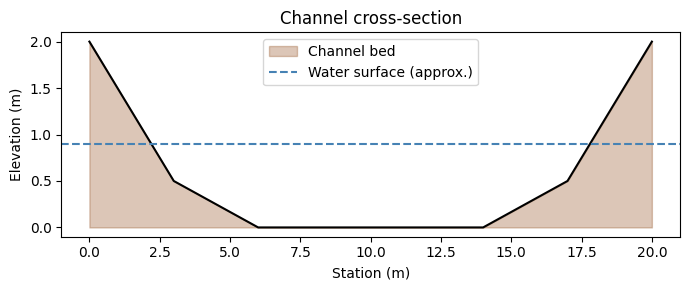

Rectangular width:  274.69 kg/s   depth = 0.974 m
Cross-section:      278.15 kg/s   depth = 1.334 m


In [10]:
# Simple trapezoidal cross-section: bank → thalweg → bank
# station (m), elevation (m above thalweg)
xs = [
    (0.0,  2.0),
    (3.0,  0.5),
    (6.0,  0.0),  # thalweg
    (14.0, 0.0),
    (17.0, 0.5),
    (20.0, 2.0),
]

geom_xs = ChannelGeometry(slope=0.005, cross_section=xs)

# Plot the cross-section
xs_x = [p[0] for p in xs]
xs_z = [p[1] for p in xs]
fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(xs_x, xs_z, alpha=0.3, color='saddlebrown', label='Channel bed')
ax.plot(xs_x, xs_z, 'k-', linewidth=1.5)
ax.axhline(0.9, color='steelblue', linestyle='--', label='Water surface (approx.)')
ax.set_xlabel('Station (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Channel cross-section')
ax.legend()
plt.tight_layout()
plt.show()

# Run Parker (1990) with the cross-section geometry
r_width = parker90.transport_rate(Q=50.0, geometry=geom,    surface_gsd=surface_gsd)
r_xs    = parker90.transport_rate(Q=50.0, geometry=geom_xs, surface_gsd=surface_gsd)
print(f"Rectangular width:  {r_width.total_bedload_kgs:.2f} kg/s   depth = {r_width.flow_depth_m:.3f} m")
print(f"Cross-section:      {r_xs.total_bedload_kgs:.2f} kg/s   depth = {r_xs.flow_depth_m:.3f} m")

## 7. Fraction-by-fraction bedload

`TransportResult.bedload_by_fraction` gives the transport rate for each grain-size class,
which is useful for budgeting or comparing with sieve-trap observations.

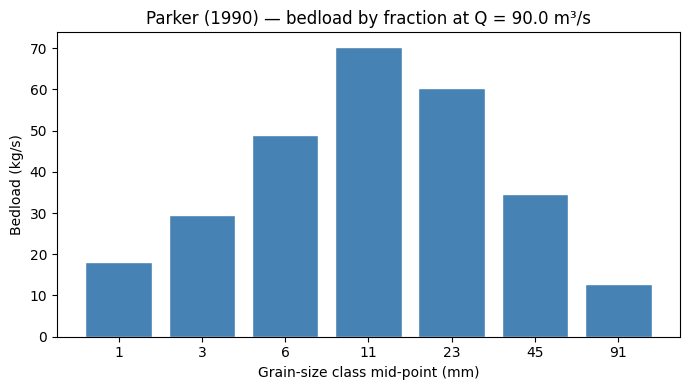

Total: 274.69 kg/s  |  Sum of fractions: 274.69 kg/s


In [11]:
from bags.grain_size import fraction_volumes

result = parker90.transport_rate(Q=50.0, geometry=geom, surface_gsd=surface_gsd)
_, Di_m, _ = fraction_volumes(surface_gsd)
Di_mm = [d * 1000 for d in Di_m]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    range(len(Di_mm)),
    result.bedload_by_fraction,
    tick_label=[f'{d:.0f}' for d in Di_mm],
    color='steelblue', edgecolor='white',
)
ax.set_xlabel('Grain-size class mid-point (mm)')
ax.set_ylabel('Bedload (kg/s)')
ax.set_title(f'Parker (1990) — bedload by fraction at Q = {Q} m³/s')
plt.tight_layout()
plt.show()

print(f"Total: {result.total_bedload_kgs:.2f} kg/s  |  "
      f"Sum of fractions: {sum(result.bedload_by_fraction):.2f} kg/s")

## 8. Monte Carlo uncertainty analysis

All equation parameters are keyword arguments, so parameter uncertainty can be
propagated by perturbing them across an ensemble of runs.

Q = 50 m³/s  |  Parker (1990)  |  n = 2000 Monte Carlo runs
5th pct: 256.89 kg/s    Median: 274.95 kg/s    95th pct: 294.91 kg/s


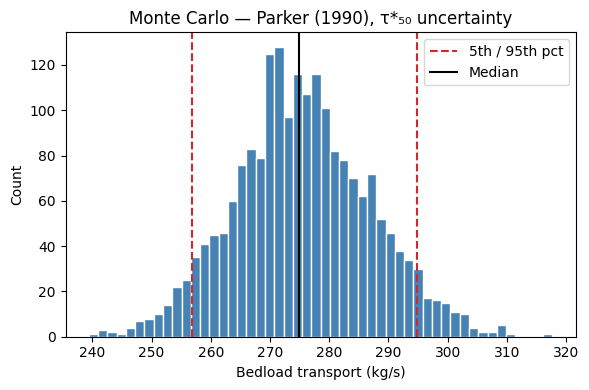

In [12]:
rng = np.random.default_rng(42)
n_mc = 2000

# Perturb Parker (1990) reference Shields stress ±10 % (1-sigma)
taursgo_samples = rng.normal(loc=0.0386, scale=0.0039, size=n_mc)   # 10 % CV

mc_qs = np.array([
    parker90.transport_rate(
        Q=50.0, geometry=geom, surface_gsd=surface_gsd,
        taursgo=t,
    ).total_bedload_kgs
    for t in taursgo_samples
])

p5, p50, p95 = np.percentile(mc_qs, [5, 50, 95])
print(f"Q = 50 m³/s  |  Parker (1990)  |  n = {n_mc} Monte Carlo runs")
print(f"5th pct: {p5:.2f} kg/s    Median: {p50:.2f} kg/s    95th pct: {p95:.2f} kg/s")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mc_qs, bins=50, color='steelblue', edgecolor='white')
ax.axvline(p5,  color='C3', linestyle='--', label='5th / 95th pct')
ax.axvline(p95, color='C3', linestyle='--')
ax.axvline(p50, color='black', linestyle='-', label='Median')
ax.set_xlabel('Bedload transport (kg/s)')
ax.set_ylabel('Count')
ax.set_title('Monte Carlo — Parker (1990), τ*₅₀ uncertainty')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Loading data from files

The `bags.io` module provides thin loaders for GSD and geometry data.

In [13]:
# Write example files and reload them
import tempfile, pathlib, json
from bags.io import load_gsd, load_cross_section, load_geometry

with tempfile.TemporaryDirectory() as tmp:
    tmp = pathlib.Path(tmp)

    # GSD CSV
    gsd_csv = tmp / 'surface_gsd.csv'
    gsd_csv.write_text('size_mm,pct_finer\n' +
        '\n'.join(f'{s},{f}' for s, f in zip(surface_gsd.sizes_mm, surface_gsd.finer_pct)))
    gsd_loaded = load_gsd(gsd_csv)

    # Cross-section CSV
    xs_csv = tmp / 'channel_xs.csv'
    xs_csv.write_text('station_m,elev_m\n' + '\n'.join(f'{x},{z}' for x, z in xs))
    xs_loaded = load_cross_section(xs_csv)

    # Geometry JSON
    geom_json = tmp / 'channel.json'
    geom_json.write_text(json.dumps({'slope': 0.005, 'width': 20.0}))
    geom_loaded = load_geometry(geom_json)

    r = parker90.transport_rate(Q=50.0, geometry=geom_loaded, surface_gsd=gsd_loaded)
    print(f"Loaded from files → {r.total_bedload_kgs:.2f} kg/s")
    print(f"Cross-section points loaded: {len(xs_loaded)}")

Loaded from files → 274.69 kg/s
Cross-section points loaded: 6


---

## Attribution

The equations, constants, and calibration logic in this library are translated directly
from the original BAGS VBA/Excel source code developed by the
**USDA Forest Service Stream Systems Technology Center** (<http://www.stream.fs.fed.us/>).

**Original BAGS technical contributors:** John Pitlick · Peter Wilcock · John Potyondy · Paul Bakke · Yantao Cui  
**Original software design and coding:** Dr. Yantao Cui  
**Version:** 2008.11 (November 2008)

Neither the Forest Service nor the original authors are responsible for damages
resulting from the use of this software.